In [3]:
# ============================================================
# PRACTICAL NO. 03
# IMAGE CLASSIFICATION USING CNN
# USING SMALL MNIST DATASET
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ============================================================
# 1. LOAD INBUILT MNIST DATASET
# ============================================================

(X_train, y_train), (X_test, y_test) = \
    tf.keras.datasets.mnist.load_data()



In [4]:
# ============================================================
# 2. USE SMALLER DATASET
# ============================================================

X_train = X_train[:5000]
y_train = y_train[:5000]

X_test = X_test[:1000]
y_test = y_test[:1000]

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# ============================================================
# 3. PREPROCESSING
# NORMALIZATION AND RESHAPING
# ============================================================

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# ============================================================
# 4. CLASS NAMES
# ============================================================

class_names = [
    "0", "1", "2", "3", "4",
    "5", "6", "7", "8", "9"
]

# ============================================================
# 5. BUILD CNN MODEL
# ============================================================

model = Sequential([

    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        10,
        activation="softmax"
    )
])

# ============================================================
# 6. COMPILE MODEL
# ============================================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)



Training Data Shape: (5000, 28, 28)
Testing Data Shape: (1000, 28, 28)


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# ============================================================
# 7. DISPLAY MODEL SUMMARY
# ============================================================

model.summary()

# ============================================================
# 8. TRAIN MODEL
# ============================================================

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

# ============================================================
# 9. EVALUATE MODEL
# ============================================================

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6855 - loss: 0.9811 - val_accuracy: 0.9130 - val_loss: 0.2924
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9030 - loss: 0.3257 - val_accuracy: 0.9360 - val_loss: 0.2165
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9358 - loss: 0.2143 - val_accuracy: 0.9520 - val_loss: 0.1784
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9408 - loss: 0.1853 - val_accuracy: 0.9560 - val_loss: 0.1550
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9553 - loss: 0.1595 - val_accuracy: 0.9480 - val_loss: 0.1594
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9550 - loss: 0.1380

Test Loss: 0.13796749711036682
Test Accuracy: 0.9549999833106995


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


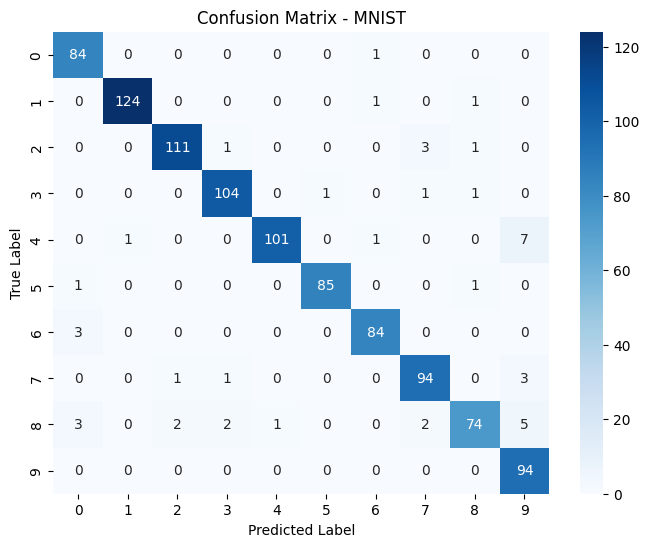

In [6]:
# ============================================================
# 10. MAKE PREDICTIONS
# ============================================================

predictions = model.predict(X_test)

y_pred = np.argmax(
    predictions,
    axis=1
)

# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - MNIST")

plt.show()



In [7]:
# ============================================================
# 12. CLASSIFICATION REPORT
# ============================================================

print("\nCLASSIFICATION REPORT\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)




CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.92      0.99      0.95        85
           1       0.99      0.98      0.99       126
           2       0.97      0.96      0.97       116
           3       0.96      0.97      0.97       107
           4       0.99      0.92      0.95       110
           5       0.99      0.98      0.98        87
           6       0.97      0.97      0.97        87
           7       0.94      0.95      0.94        99
           8       0.95      0.83      0.89        89
           9       0.86      1.00      0.93        94

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.96      0.95      0.95      1000



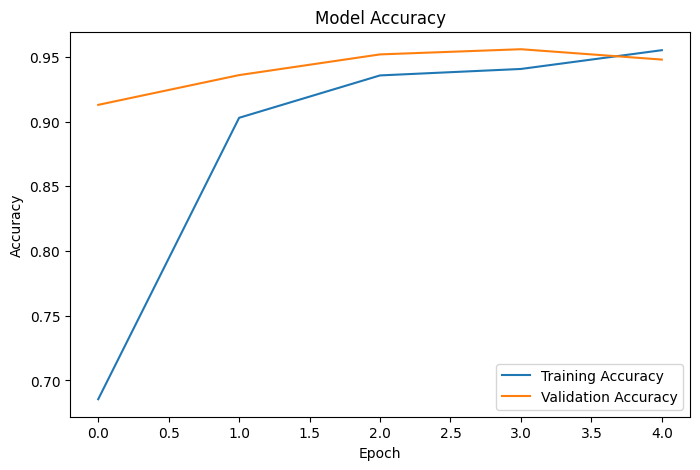

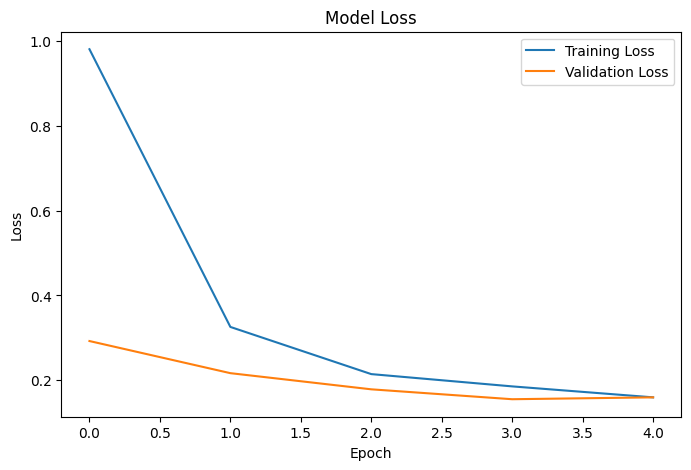

In [8]:
# ============================================================
# 13. TRAINING AND VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

# ============================================================
# 14. TRAINING AND VALIDATION LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

